In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def calculate_psi_profile(zf, z,
                          psi_f=-0.1,
                          transition_width=0.15):
    """
    Parameters:
    zf (float): Wetting front depth (m)
    z (float):  A vector of depths
    psi_f (float): Psi at the wetting front (m)
    transition_width (float): A transition width to smooth the psi profile (m)
    """

    smoothing_mask = 0.5 * (1 - np.tanh((z[:,np.newaxis]- zf) / (transition_width / 2)))
    psi_hydro = zf - z[:,np.newaxis]
    psi = (psi_hydro * smoothing_mask) + (psi_f * (1 - smoothing_mask))

    return psi

In [3]:
# PARAMETERS
c_prime =200                           # Cohesion (Pa)
phi_prime_deg = 36.7                   # Internal friction angle
phi_prime = np.radians(phi_prime_deg)  
delta_deg = 30                         # Field-based slope angle
delta = np.radians(delta_deg)        

sigma = 2700        # Grain density (kg/m^3)
rho_w = 1000        # Water density (kg/m^3)
C_star = 0.65       # Sediment concentration (-)
g = 9.81            # Gravity const (m/s^2)

rho_sat = (C_star * sigma) + ((1.0 - C_star) * rho_w)
gamma_s = rho_sat * g
gamma_w = rho_w * g

h0 = 0.125 # Surface water depth [m]

# DEPTH ARRAY
depths = np.linspace(0.001, 0.3, 500)  # Infiltration/failure depth in meters

# Array for outputs
fs_trigrs = np.ones((500,500))
fs_takahashi = []

In [4]:
# Main loop
for i,Z in enumerate(depths):

    # ---------------TRIGRS---------------------
    psi = calculate_psi_profile(Z, depths)
    sigma_total = gamma_s * depths * (np.cos(delta) ** 2)

    # Note: if psi is negative (suction), this increases effective stress
    pore_pressure = psi * gamma_w
    sigma_prime = sigma_total[:,np.newaxis] - pore_pressure

    sigma_prime = np.maximum(sigma_prime, 0)

    # The numerator is the total resisting shear strength
    num = c_prime+ (sigma_prime * np.tan(phi_prime))
    den = gamma_s * depths * np.sin(delta) * np.cos(delta)

    fs = np.divide(num, den[:,np.newaxis],
                           where=den[:,np.newaxis]>0,
                           out=np.ones_like(num))

    fs_trigrs[:,i]=fs[:,0]

    # ----------------TAKAHASHI--------------------------
    num_tak = (g * np.cos(delta) * C_star * (sigma - rho_w) * Z * np.tan(phi_prime)) + c_prime
    den_tak = g * np.sin(delta) * ((C_star * (sigma - rho_w) * Z) + (rho_w * (Z + h0)))
    
    fs_t = np.divide(num_tak,
                     den_tak,
                     where=den_tak!=0)
    fs_takahashi.append(fs_t)

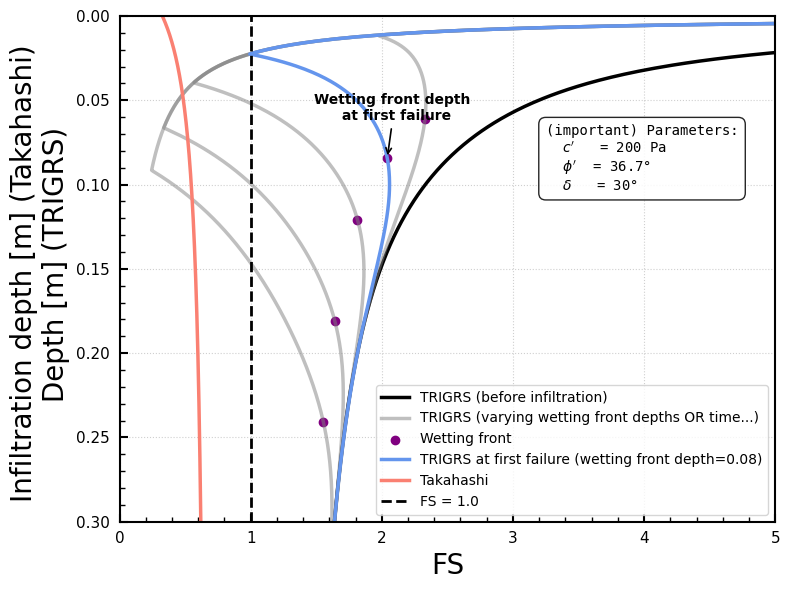

In [6]:
# PLOTTING THE RESULTS

# Lets find TRIGRS first time of failure (if any)
wf_flag=True
t_failure=-1
for t in np.arange(0,500): #range(np.shape(fs_trigrs)[0]):
    if np.any(fs_trigrs[:,t]<1) and wf_flag:
        wf_depth_failure=np.argwhere(fs_trigrs[:,t]<1)
        t_failure = t
        break



# Plot both models
plt.figure(figsize=(8, 6))

# First lets plot all profiles of TRIGRS:
for i,n in enumerate(range(0,500,100)):
    if i==0:
        plt.plot(fs_trigrs[:,n], depths,
                 color='black',
                 linewidth=2.5,
                alpha=1,
                label='TRIGRS (before infiltration)')
        plt.scatter(fs_trigrs[n, n], depths[n])

    elif i<2:
        plt.plot(fs_trigrs[:,n], depths,
         color='gray',
         linewidth=2.5,
        alpha=0.5,
        label='TRIGRS (varying wetting front depths OR time...)')
        plt.scatter(fs_trigrs[n, n], depths[n], color='purple',label='Wetting front')

    else:
        plt.plot(fs_trigrs[:,n], depths,
         color='gray',
         linewidth=2.5,
        alpha=0.5)
        plt.scatter(fs_trigrs[n, n], depths[n], color='purple')

# If TRIGRS predict failure, lets plot this profile in diffrent color
if t_failure>-1:
    plt.plot(fs_trigrs[:,int(t_failure)], depths,
             label=f'TRIGRS at first failure (wetting front depth={np.round(depths[t_failure],2)})',
             color='cornflowerblue', linewidth=2.5)
    plt.scatter(fs_trigrs[t_failure, int(t_failure)], depths[t_failure],
               color='purple')
    plt.annotate(
    'Wetting front depth \n at first failure', 
    xy=(fs_trigrs[t_failure, int(t_failure)], depths[t_failure]),       # Arrow points exactly here
    xytext=(5, 25),                           # Offset text 25 points vertically up
    textcoords='offset points',               # Relative to the xy point
    ha='center',                              # Horizontally center text over arrow
    va='bottom',                              # Vertical alignment of text box
    arrowprops=dict(
        arrowstyle='->',                      # Clean standard arrow head
        connectionstyle='arc3',               # Straight arrow line
        color='black',                        # Arrow color
        linewidth=1.2                         # Arrow thickness
    ),
    fontsize=10,
    fontweight='bold',
    color='black'
)

# Plot Takahashi profile
plt.plot(fs_takahashi, depths, label=f'Takahashi', color='salmon', linewidth=2.5)
plt.axvline(x=1.0, color='black', linestyle='--', label='FS = 1.0',
           linewidth=2)

# Boundaries and axis inversion
plt.xlim(0, 5)
plt.ylim(0.0, 0.3)
plt.gca().invert_yaxis()  # Inverts axis so 0 is at the surface and depth goes down


plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('FS', fontsize=20)
plt.ylabel('Infiltration depth [m] (Takahashi) \n Depth [m] (TRIGRS)',
           fontsize=20)


param_text = (
    f"(important) Parameters:\n"
    f"  $c'$   = {c_prime} Pa\n"
    f"  $\\phi'$  = {phi_prime_deg}°\n"
    f"  $\\delta$   = {delta_deg}°"
)

plt.text(
    0.65, 0.65,                
    param_text, 
    transform=plt.gca().transAxes,
    fontsize=10,
    fontfamily='monospace',     
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=dict(
        boxstyle='round,pad=0.5', 
        facecolor='white',     
        edgecolor='black',     
        linewidth=1.0,        
        alpha=0.85             
    )
)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  

# Adjust tick parameters (width, length, and label padding)
ax.tick_params(
    axis='both',          
    which='major',        
    direction='in',       
    length=6,            
    width=1.5,           
    colors='black',       
    labelsize=11,         
    pad=7                 
)

ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in', length=3.5, width=1.0)
plt.tight_layout()

plt.show()